<a href="https://colab.research.google.com/github/Smarth2005/UCS761-Deep-Learning/blob/main/NVIDIA-%20Fundamentals%20of%20Deep%20Learning/Multi%20Class%20Classification%20with%20MNIST%20Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
tf.__version__

'2.19.0'

In [ ]:
from tensorflow.keras.datasets.mnist import load_data
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

In [ ]:
(X_train, y_train), (X_test, y_test) = load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((60000, 28, 28), (10000, 28, 28), (60000,), (10000,))

This means 60,000 images have been sampled in the training set, each of shape
 28 x 28. Similarly test set has 10,000 images of same shape.

In [ ]:
set(y_train)

{np.uint8(0),
 np.uint8(1),
 np.uint8(2),
 np.uint8(3),
 np.uint8(4),
 np.uint8(5),
 np.uint8(6),
 np.uint8(7),
 np.uint8(8),
 np.uint8(9)}

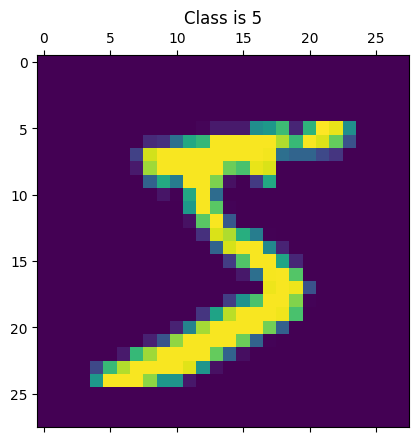

In [ ]:
# Visualization
import matplotlib.pyplot as plt
plt.matshow(X_train[0])
plt.title(f"Class is {y_train[0]}")
plt.show()

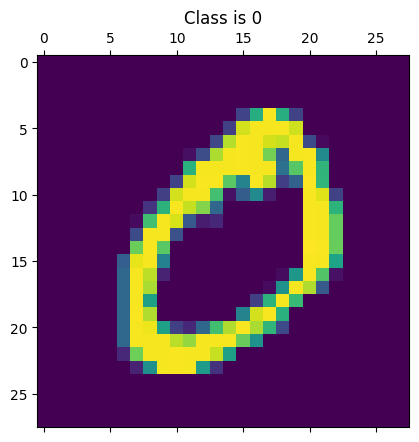

In [ ]:
plt.matshow(X_train[1])
plt.title(f"Class is {y_train[1]}")
plt.show()

In [ ]:
# Preprocessing
# Note: The image i sinterpreted n the format of pixel intensities (range: 0 to 255)

import numpy as np
np.min(X_train), np.max(X_train)


(np.uint8(0), np.uint8(255))

In [ ]:
X_train = X_train/255
X_test = X_test/255

In [ ]:
np.min(X_train), np.max(X_train)

(np.float64(0.0), np.float64(1.0))

In [ ]:
np.min(X_test), np.max(X_test)

(np.float64(0.0), np.float64(1.0))

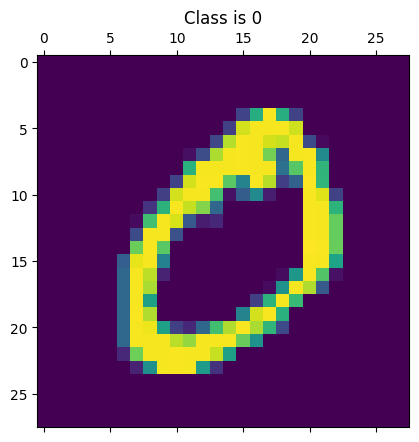

In [ ]:
plt.matshow(X_train[1])
plt.title(f"Class is {y_train[1]}")
plt.show()

In [ ]:
# flatten() ---> convert the multi-dim features to 1 dim
X_train = X_train.reshape(60000, 784)
X_test = X_test.reshape(10000, 784)

In [ ]:
y_train[:5]

array([5, 0, 4, 1, 9], dtype=uint8)

In [ ]:
# Target
y_train = tf.keras.utils.to_categorical(y_train) # one-hot encoding
y_test = tf.keras.utils.to_categorical(y_test)

In [ ]:
y_train[:5]

array([[0., 0., 0., 0., 0., 1., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1.]])

In [ ]:
# Model
model = Sequential()
model.add(Dense(256, activation='relu', input_shape=[784,], name="h1"))
model.add(Dense(128, activation='relu', name="h2"))
model.add(Dense(10,  activation='softmax')) # 10 classes
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ h1 (Dense)                      │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ h2 (Dense)                      │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 235,146 (918.54 KB)

 Trainable params: 235,146 (918.54 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.layers[0].get_weights() # return both weights and bias

[array([[ 0.05128837,  0.01377977,  0.03814234, ...,  0.05726929,
          0.05192551,  0.04047837],
        [-0.0274305 , -0.05957498, -0.04619359, ..., -0.03345722,
         -0.05196508,  0.04335018],
        [ 0.05165522,  0.04711142, -0.06487596, ..., -0.06287288,
          0.04439407,  0.07183635],
        ...,
        [-0.02681747,  0.04760507, -0.00196838, ...,  0.04119393,
          0.00459561,  0.02452428],
        [ 0.04498131, -0.04490235,  0.01234748, ...,  0.04242766,
          0.00907291,  0.05271132],
        [ 0.0236114 , -0.07373628,  0.07332642, ..., -0.04532395,
         -0.01067997,  0.04180565]], dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.

In [ ]:
model.compile(optimizer = 'rmsprop',
              loss = 'categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
history = model.fit(x=X_train, y=y_train,
                    epochs=25,
                    batch_size=32,
                    validation_data=(X_test, y_test))

Epoch 1/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.8917 - loss: 0.3565 - val_accuracy: 0.9676 - val_loss: 0.1099
Epoch 2/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9727 - loss: 0.0910 - val_accuracy: 0.9747 - val_loss: 0.0956
Epoch 3/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9808 - loss: 0.0656 - val_accuracy: 0.9755 - val_loss: 0.0937
Epoch 4/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9859 - loss: 0.0479 - val_accuracy: 0.9698 - val_loss: 0.1169
Epoch 5/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9896 - loss: 0.0364 - val_accuracy: 0.9798 - val_loss: 0.0806
Epoch 6/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9909 - loss: 0.0312 - val_accuracy: 0.9784 - val_loss: 0.1013
Epoch 7/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9921 - loss: 0.0288 - val_accuracy: 0.9772 - val_loss: 0.1120
Epoch 8/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9935 - loss: 0

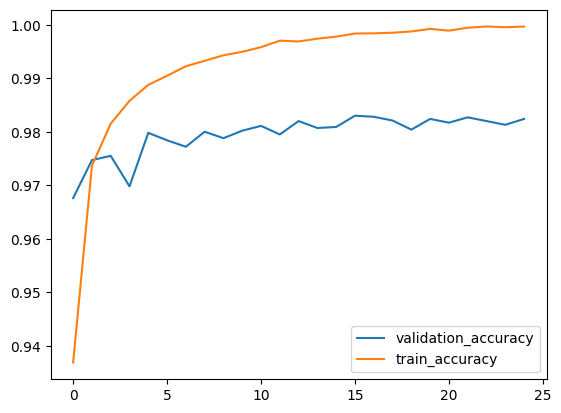

In [ ]:
h = history.history

plt.plot(h['val_accuracy'], label='validation_accuracy')
plt.plot(h['accuracy'], label='train_accuracy')
plt.legend()
plt.show()

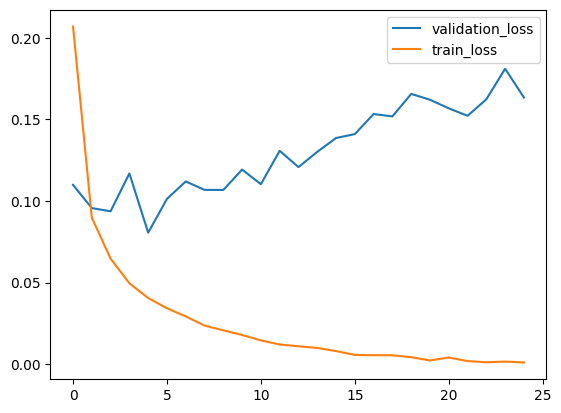

In [ ]:
plt.plot(h['val_loss'], label='validation_loss')
plt.plot(h['loss'], label='train_loss')
plt.legend()
plt.show()

In [ ]:
model.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9793 - loss: 0.2061


[0.16344374418258667, 0.9824000000953674]